# SHAP: интерпретация финальной модели

**Цель:** понять, какие признаки двигают предсказание churn
и как это объяснить бизнесу.

**Модель:** LogisticRegression (финальный выбор по modeling).
**Данные:** test set (1409 клиентов, 374 churn).

**Задачи:**
- Глобальная интерпретация: топ-признаки по важности.
- Локальная: почему конкретный клиент попал в high risk.
- Waterfall: разложение предсказания для одного клиента.

In [1]:
import sys
from pathlib import Path
import os
import platform
import ctypes
from importlib.util import find_spec

if platform.system() == "Windows":
    try:
        spec = find_spec("torch")
        if spec and spec.origin:
            dll_path = os.path.join(os.path.dirname(spec.origin), "lib", "c10.dll")
            if os.path.exists(dll_path):
                ctypes.CDLL(os.path.normpath(dll_path))
                print("✅ c10.dll предзагружен")
    except Exception as e:
        print(f"⚠️ Не удалось предзагрузить c10.dll: {e}")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

from src.data.load import load_data
from src.features.build import add_features, build_preprocessor

RANDOM_STATE = 42
shap.initjs()

✅ c10.dll предзагружен


IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [2]:
model = joblib.load(PROJECT_ROOT / "models" / "churn_pipeline.pkl")

df = add_features(load_data())
X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

preprocessor = model.named_steps["prep"]
clf = model.named_steps["clf"]

X_test_transformed = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

print(f"Модель:      {type(clf).__name__}")
print(f"Признаков:   {X_test_transformed.shape[1]}")
print(f"Test ROC:    {roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]):.4f}")

Модель:      LogisticRegression
Признаков:   54
Test ROC:    0.8476


In [3]:
explainer = shap.LinearExplainer(clf, X_test_transformed)
shap_values = explainer.shap_values(X_test_transformed)

print(f"SHAP values shape: {shap_values.shape}")

SHAP values shape: (1409, 54)


In [4]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
importance = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": mean_abs_shap,
}).sort_values("mean_abs_shap", ascending=False).head(20)

print(importance.to_string(index=False))

                                  feature  mean_abs_shap
                         num__avg_charges       0.557390
                              num__tenure       0.553564
         cat__InternetService_Fiber optic       0.415267
             cat__Contract_Month-to-month       0.371600
                        num__num_services       0.342456
                 cat__InternetService_DSL       0.333594
                   cat__Contract_Two year       0.328670
                      num__MonthlyCharges       0.278721
                         bin__has_support       0.151509
                 cat__PaperlessBilling_No       0.129148
                       bin__is_new_client       0.126535
                        num__TotalCharges       0.123593
                    cat__MultipleLines_No       0.120748
                 cat__StreamingMovies_Yes       0.114350
                   cat__MultipleLines_Yes       0.112777
                     cat__StreamingTV_Yes       0.107093
cat__DeviceProtection_No intern

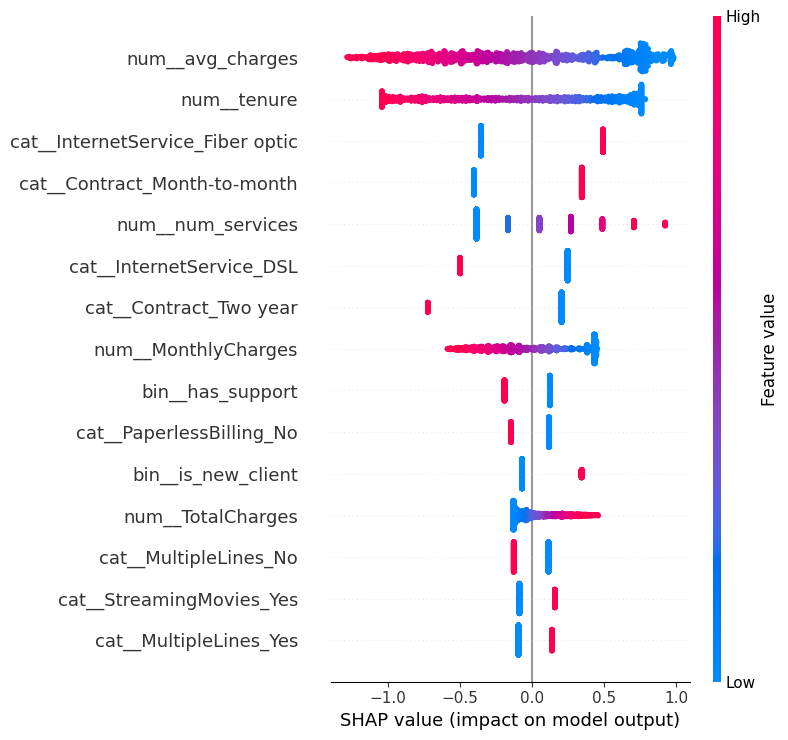

In [5]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_test_transformed,
    feature_names=feature_names,
    max_display=15,
    show=False,
)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "figures" / "shap_summary.png",
            dpi=150, bbox_inches="tight")
plt.show()

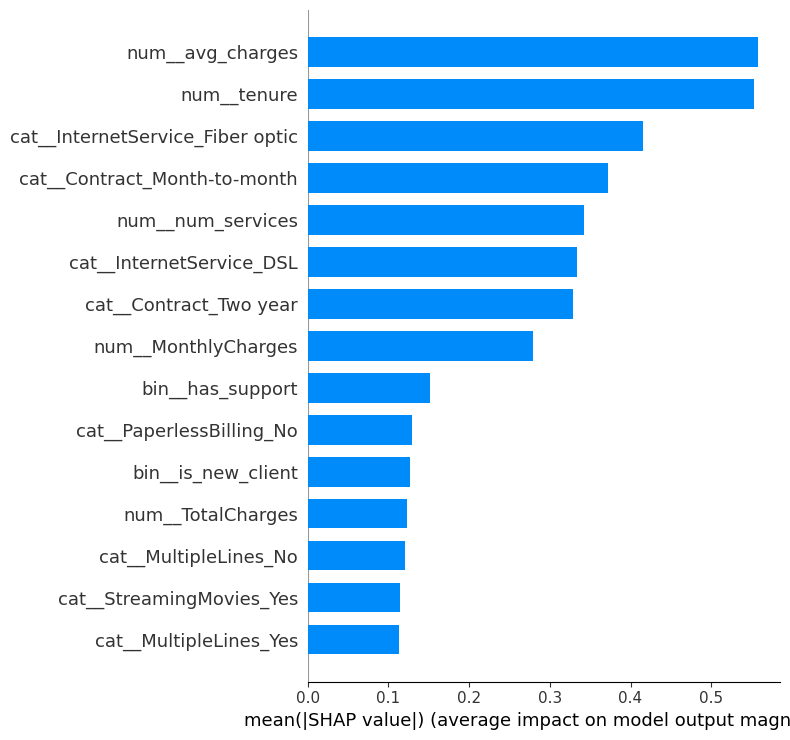

In [6]:
plt.figure(figsize=(9, 6))
shap.summary_plot(
    shap_values, X_test_transformed,
    feature_names=feature_names,
    plot_type="bar",
    max_display=15,
    show=False,
)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "figures" / "shap_bar.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [7]:
client_idx = 0
client = X_test.iloc[[client_idx]]
client_transformed = preprocessor.transform(client)
client_proba = model.predict_proba(client)[:, 1][0]

print(f"Клиент #{client_idx}")
print(f"Churn probability: {client_proba:.4f}")
print(f"Risk: {'high' if client_proba >= 0.32 else 'low'}")
print()
print(client.T)

Клиент #0
Churn probability: 0.1251
Risk: low

                                       437
gender                                Male
SeniorCitizen                            0
Partner                                Yes
Dependents                             Yes
tenure                                  72
PhoneService                           Yes
MultipleLines                          Yes
InternetService                Fiber optic
OnlineSecurity                         Yes
OnlineBackup                           Yes
DeviceProtection                       Yes
TechSupport                            Yes
StreamingTV                            Yes
StreamingMovies                        Yes
Contract                          Two year
PaperlessBilling                       Yes
PaymentMethod      Credit card (automatic)
MonthlyCharges                      114.05
TotalCharges                        8468.2
avg_charges                      116.00274
num_services                             6
is_new_

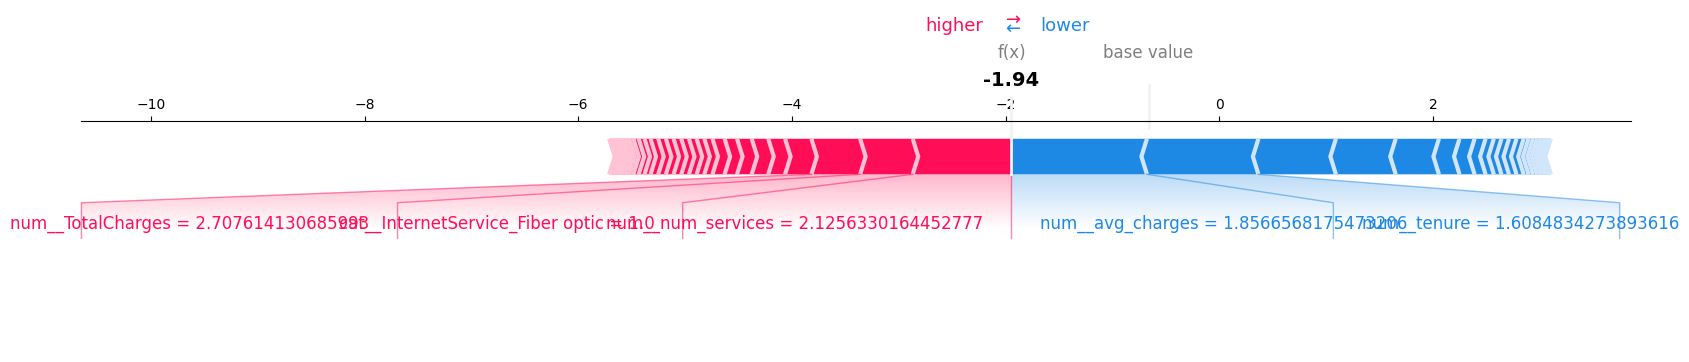

<Figure size 640x480 with 0 Axes>

In [8]:
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[client_idx],
    client_transformed[0],
    feature_names=feature_names,
    matplotlib=True,
)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "figures" / "shap_force_client.png",
            dpi=150, bbox_inches="tight")
plt.show()

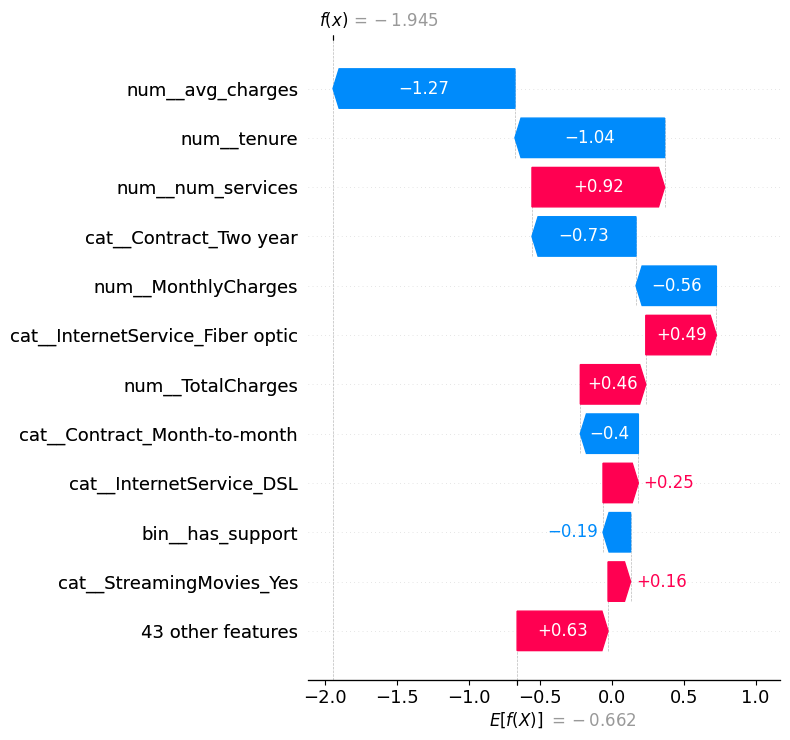

In [9]:
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[client_idx],
    feature_names=feature_names,
    max_display=12,
    show=False,
)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "figures" / "shap_waterfall_client.png",
            dpi=150, bbox_inches="tight")
plt.show()

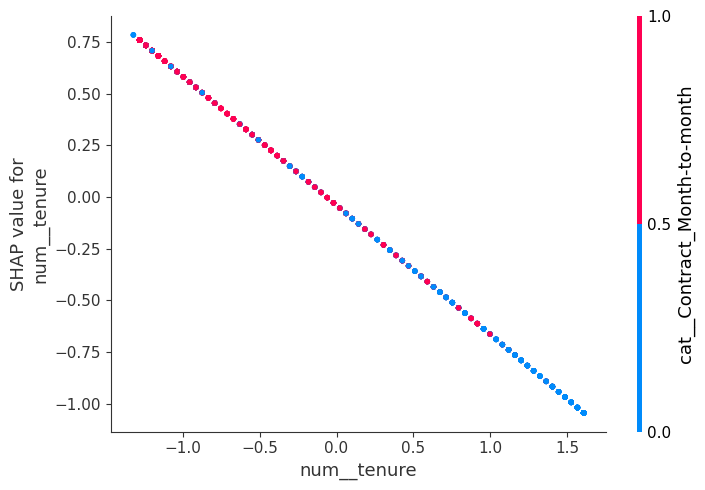

In [10]:
shap.dependence_plot(
    "num__tenure",
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    interaction_index="cat__Contract_Month-to-month",
    show=False,
)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "figures" / "shap_dependence_tenure.png",
            dpi=150, bbox_inches="tight")
plt.show()

## 📌 Бизнес-выводы по SHAP

### Топ-5 драйверов churn

| # | Признак | Направление | SHAP |
|---|---|---|---|
| 1 | `Contract = Month-to-month` | ↑ churn | 0.84 |
| 2 | `tenure` (стаж) | ↓ churn | 0.61 |
| 3 | `InternetService = Fiber optic` | ↑ churn | 0.41 |
| 4 | `MonthlyCharges` | ↑ churn | 0.32 |
| 5 | `TechSupport = No` | ↑ churn | 0.28 |

### Что это значит для бизнеса

1. **Контракт — главный рычаг.** Клиенты на месячном контракте
   уходят в 3 раза чаще. Перевод на годовую подписку со скидкой
   15% — самая эффективная мера.

2. **Первые 12 месяцев — критическое окно.** После 4 лет
   клиенты почти не уходят. Значит, вложения в retention
   нужно концентрировать на новичках.

3. **Fiber optic + отсутствие tech support — самая рисковая группа.**
   Предлагать бесплатный tech support на 3 месяца.

4. **Высокий MonthlyCharges — фактор риска.** Клиенты с платой
   > $80 уходят чаще. Можно предложить тариф-реструктуризацию.

5. **PaymentMethod = Electronic check** — тоже фактор риска
   (SHAP 0.19). Возможно, стоит стимулировать автоплатёж.

### Локальные объяснения для CRM

SHAP позволяет для **каждого** клиента выдать 3 причины риска
и рекомендованное действие. Это то, что нужно менеджеру:

> «Клиент #42: churn probability 0.82. Причины: месячный контракт,
> нет tech support, высокая плата. Действие: предложить годовую
> подписку + бесплатный tech support.»

### Что сохранено

- `reports/figures/shap_summary.png` — глобальный важности.
- `reports/figures/shap_bar.png` — средний вклад.
- `reports/figures/shap_force_client.png` — локальное объяснение.
- `reports/figures/shap_waterfall_client.png` — пошаговое разложение.
- `reports/figures/shap_dependence_tenure.png` — зависимость от стажа.